If the condition is INCORRECT, rewrite the prompt into a websearch-friendly query before searching web_docs.

In [2]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from pydantic import BaseModel

# from langchain_community.tools.tavily_search import TavilySearchResults #deprecated
from langchain_tavily import TavilySearch  #added ✅

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import re

load_dotenv()

C:\Users\Mirha\AppData\Local\Temp\ipykernel_3392\31815303.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\Mirha\Personal\AI Engineering\RAGs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [10]:
# 1)loading
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)
len(docs)

1322

In [11]:
# 2) chunking
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError , to replace weird characters from pdf and run error free
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [12]:
len(chunks)

4117

In [13]:
# 4) embeddings & vector store & retriver
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type='similarity' ,search_kwargs={'k':4})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3121.05it/s]


In [14]:
# llm
llm = ChatGroq(model="llama-3.1-8b-instant")
# model = ChatGoogleGenerativeAI(model="gemini-3.1-pro-preview")
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [34]:
class State(TypedDict):
    question : str
    docs : list[Document]

    good_docs: list[Document]
    verdict : str
    reason : str

    strips : list[str]      #decomposition output (sentences strips)
    kept_strips : list[str] #sentences to keep 
    refined_context : str   #knowledge internal (K internal)     

    web_query : str
    web_docs : list[Document]  #added ⭐
    

    answer : str

In [35]:
#node 1
def retrieves_docs(state:State) -> State:
    question = state['question']
    return {'docs': retriever.invoke(question)}

In [36]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [37]:
# node 2   "Retrieval Evaluator"
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON ONLY.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)



doc_eval_chain = doc_eval_prompt | model.with_structured_output(DocEvalScore)


#---------------------------------------------------------------
#  evaluation node 
# --------------------------------------------------------------- 
def docs_evaluation(state: State) -> State:
    q = state['question']

    scores: list[float] = []
    reasons: list[str] = []
    good_docs: list[Document] = []

    for d in state['docs']:
        out = doc_eval_chain.invoke({'question':q, 'chunk': d})
        scores.append(out.score)
        reasons.append(out.reason)


        if out.score > LOWER_TH:
            good_docs.append(d)

    # correct condition
    if any(s>UPPER_TH for s in scores):
        return{
            "good_docs": good_docs,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # incorrect condition
    if len(scores)>0 and all(s<LOWER_TH for s in scores):
        why = "chunks were irrelevant"
        return{
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}"
        }
    
    # ambiguous condition 
    why = "retrived chunks were ambiguous"
    return{
        "good_docs": [],
        "verdict": "AMBIGUOUs",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}"
    }



In [38]:
# tavily search node (if incorrect then do web seasrch and get "web_docs") "KNOWLEDGE SEARCHING"
tavily = TavilySearch(max_results=5)

def web_search_docs_node(state:State) -> State:
    q = state.get("web_query") or state["question"]

    result = tavily.invoke(q)

    web_docs = []
    for r in result['results'] or []:
        title = r['title']
        url = r['url']
        content = r['content']

        text = f"title: {title}\n content: {content}\n url: {url}"
        web_docs.append(Document(page_content=text,metadata={'title':title,'url':url}))

        return {'web_docs':web_docs}

In [39]:
# (INCORRECT condition rewriting the query before sending to websearch docs 


class webQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages([
    (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}")
])

chain = rewrite_prompt | model.with_structured_output(webQuery)

def rewrite_query_node(state:State) -> State:
    out = chain.invoke({'question': state['question']})
    return {'web_query': out.query}

In [40]:
# node 3  (refine node when correct or incorrect both)

# -----------------------------
# 1st part Sentence-level DECOMPOSER  (will split paragraph into list of sentences )
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class keeporDROP(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate([
    ("system",
    "You are a strict relevance filter.\n"
    "Return keep=true only if the sentence directly helps answer the question.\n"
    "Use ONLY the sentence. Output JSON only."),
    ("user","Question: {question}\n\nSentence:\n{sentence}")
])
# 2nd part

filter_chain = filter_prompt | llm.with_structured_output(keeporDROP)

# -------------------------------------------------------------------------------------
# REFINING (Decompose -> Filter -> Recompose)  
# -------------------------------------------------------------------------------------
def refine(state: State) -> State:

    q = state["question"]

    # update condition ⭐
    if state['verdict']=="CORRECT":
        # Combine retrieved docs into one context string
        context = "\n\n".join(d.page_content for d in state['good_docs']).strip()
    else:
        context = "\n\n".join(d.page_content for d in state['web_docs']).strip()


    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [41]:
#node 4
prompt = ChatPromptTemplate([
    ("system",
    "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
    "If the bullets are empty or insufficient, say: 'I don't know based on the provided books."),
    ("user","Question: {question}\n\nRefined context:\n{refined_context}")
])

def generate(state:State) -> State:
    context = "\n\n".join(d.page_content for d in state['docs'])
    out = (prompt | llm).invoke({'question':state['question'],'refined_context':state['refined_context']}).content
    return {'answer':out}

In [42]:
def ambiguous_node(state:State) -> State:
    return {'answer':f"Ambiguoug : {state['reason']}"}

def route_condition(state:State) -> str:
    if state['verdict'] == "CORRECT":
        return "correct"
    elif state['verdict']== "INCORRECT":
        return "incorrect"
    else:
        return "ambiguous"
    

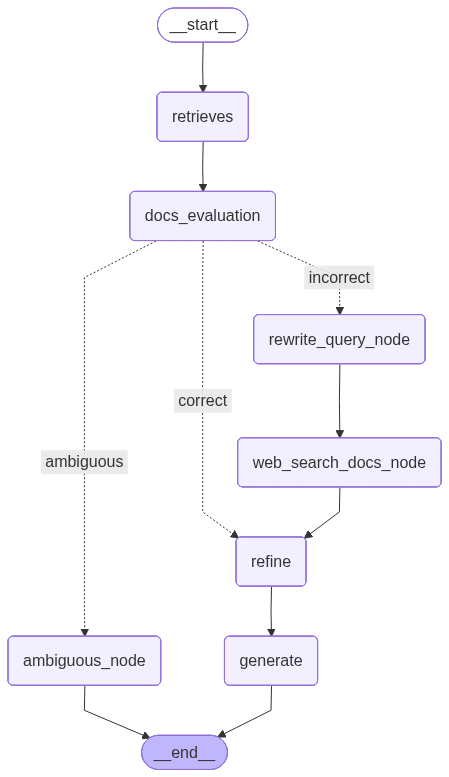

In [43]:
graph = StateGraph(State)

graph.add_node('retrieves',retrieves_docs)
graph.add_node('docs_evaluation',docs_evaluation)
graph.add_node('rewrite_query_node',rewrite_query_node)
graph.add_node('web_search_docs_node',web_search_docs_node)
graph.add_node('ambiguous_node',ambiguous_node)
graph.add_node('refine',refine)
graph.add_node('generate',generate)

graph.add_edge(START,'retrieves')
graph.add_edge('retrieves','docs_evaluation')
graph.add_conditional_edges('docs_evaluation',route_condition,
                            {"correct":"refine","incorrect":"rewrite_query_node","ambiguous":"ambiguous_node"})
graph.add_edge('rewrite_query_node','web_search_docs_node')
graph.add_edge('web_search_docs_node','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)

graph = graph.compile()

graph

In [44]:
result = graph.invoke(
    {
        "question": "AI news from last month",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", result["verdict"])
print("REASON:", result["reason"])
print("\nOUTPUT:\n", result["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. chunks were irrelevant

OUTPUT:
 • **Merck and Google Cloud** reached a $1 billion AI drug development deal.
• Microsoft to invest $10 billion in Japan for AI and cyber defence expansion.
• Google released AI features to make data entry a thing of the past.


In [45]:
print(result['web_query'])

AI news (last 30 days)


In [ ]:
# tavily testing  (google search may give some good and some bad answers as well )

# tavily = TavilySearch(max_results=5).invoke("what is AI?")
# print(tavily)
# tavily['results']
# main_content = "\n\n".join(c['content'] for c in tavily['results'])
# print(main_content)

{'query': 'what is AI?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.mckinsey.com/featured-insights/mckinsey-explainers/what-is-ai', 'title': 'What is AI (artificial intelligence)? - McKinsey', 'content': "Artificial intelligence is a machine's ability to perform some cognitive functions we usually associate with human. The volume and complexity of", 'score': 0.84027237, 'raw_content': None}, {'url': 'https://www.sas.com/en_us/insights/analytics/what-is-artificial-intelligence.html', 'title': 'Artificial Intelligence (AI): What it is and why it matters - SAS', 'content': "Learn to use your software. Learn why SAS is the world's most trusted analytics platform, and why analysts, customers and industry experts love SAS. Artificial intelligence (AI) makes it possible for machines to learn from experience, adjust to new inputs and perform human-like tasks. Most AI examples that you hear about today – from chess-playing computers to self-drivi

[{'url': 'https://www.mckinsey.com/featured-insights/mckinsey-explainers/what-is-ai',
  'title': 'What is AI (artificial intelligence)? - McKinsey',
  'content': "Artificial intelligence is a machine's ability to perform some cognitive functions we usually associate with human. The volume and complexity of",
  'score': 0.84027237,
  'raw_content': None},
 {'url': 'https://www.sas.com/en_us/insights/analytics/what-is-artificial-intelligence.html',
  'title': 'Artificial Intelligence (AI): What it is and why it matters - SAS',
  'content': "Learn to use your software. Learn why SAS is the world's most trusted analytics platform, and why analysts, customers and industry experts love SAS. Artificial intelligence (AI) makes it possible for machines to learn from experience, adjust to new inputs and perform human-like tasks. Most AI examples that you hear about today – from chess-playing computers to self-driving cars – rely heavily on deep learning and natural language processing. Using the

Artificial intelligence is a machine's ability to perform some cognitive functions we usually associate with human. The volume and complexity of

Learn to use your software. Learn why SAS is the world's most trusted analytics platform, and why analysts, customers and industry experts love SAS. Artificial intelligence (AI) makes it possible for machines to learn from experience, adjust to new inputs and perform human-like tasks. Most AI examples that you hear about today – from chess-playing computers to self-driving cars – rely heavily on deep learning and natural language processing. Using these technologies, computers can be trained to accomplish specific tasks by processing large amounts of data and recognizing patterns in the data. The term artificial intelligence was coined in 1956, but AI has become more popular today thanks to increased data volumes, advanced algorithms, and improvements in computing power and storage. This early work paved the way for the automation and formal 